Flagging Vendor Invoices for Manual Review

Objective: Predict whether a vendor invoice should be flagged for manual approval based on abnormal cost, freight, or delivery patterns, in order to reduce
financial risk, improve operational efficiency, and prioritize human review where it adds the most value.

. Manual invoice review is time-consuming and does not scale with transaction volume.
· Abnormal freight charges, pricing deviations, or delivery delays often indicate errors, disputes, or compliance risks.
. An automated flagging system enables finance teams to focus attention on high-risk invoices while allowing low-risk invoices to be processed automatically.

In [72]:
import sqlite3
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt


In [73]:
from pathlib import Path

db_candidates = [
    Path("ML_project/data/inventory.db"),
    Path("../data/inventory.db"),
    Path("data/inventory.db"),
]
db_path = next((p for p in db_candidates if p.exists()), None)
if db_path is None:
    raise FileNotFoundError("Could not find inventory.db in expected locations.")

conn = sqlite3.connect(str(db_path))
print(f"Connected to: {db_path}")

Connected to: ..\data\inventory.db


In [74]:
tables = pd.read_sql_query("SELECT name FROM sqlite_master WHERE type='table'", conn)
for table_name in tables["name"]:
    print(f"Table name: {table_name}")
    sample_df = pd.read_sql_query(f"SELECT * FROM {table_name} LIMIT 5", conn)
    display(sample_df)

Table name: purchases


,InventoryId,Store,Brand,Description,Size,VendorNumber,VendorName,PONumber,PODate,ReceivingDate,InvoiceDate,PayDate,PurchasePrice,Quantity,Dollars,Classification
0,69_MOUNTMEND_8412,69,8412,Tequila Ocho Plata Fresno,750mL,105,ALTAMAR BRANDS LLC,8124,2023-12-21,2024-01-02,2024-01-04,2024-02-16,35.71,6,214.26,1
1,30_CULCHETH_5255,30,5255,TGI Fridays Ultimte Mudslide,1.75L,4466,AMERICAN VINTAGE BEVERAGE,8137,2023-12-22,2024-01-01,2024-01-07,2024-02-21,9.35,4,37.40,1
2,34_PITMERDEN_5215,34,5215,TGI Fridays Long Island Iced,1.75L,4466,AMERICAN VINTAGE BEVERAGE,8137,2023-12-22,2024-01-02,2024-01-07,2024-02-21,9.41,5,47.05,1
3,1_HARDERSFIELD_5255,1,5255,TGI Fridays Ultimte Mudslide,1.75L,4466,AMERICAN VINTAGE BEVERAGE,8137,2023-12-22,2024-01-01,2024-01-07,2024-02-21,9.35,6,56.10,1
4,76_DONCASTER_2034,76,2034,Glendalough Double Barrel,750mL,388,ATLANTIC IMPORTING COMPANY,8169,2023-12-24,2024-01-02,2024-01-09,2024-02-16,21.32,5,106.60,1


Table name: purchase_prices


,Brand,Description,Price,Size,Volume,Classification,PurchasePrice,VendorNumber,VendorName
0,58,Gekkeikan Black & Gold Sake,12.99,750mL,750,1,9.28,8320,SHAW ROSS INT L IMP LTD
1,62,Herradura Silver Tequila,36.99,750mL,750,1,28.67,1128,BROWN-FORMAN CORP
2,63,Herradura Reposado Tequila,38.99,750mL,750,1,30.46,1128,BROWN-FORMAN CORP
3,72,No. 3 London Dry Gin,34.99,750mL,750,1,26.11,9165,ULTRA BEVERAGE COMPANY LLP
4,75,Three Olives Tomato Vodka,14.99,750mL,750,1,10.94,7245,PROXIMO SPIRITS INC.


Table name: vendor_invoice


,VendorNumber,VendorName,InvoiceDate,PONumber,PODate,PayDate,Quantity,Dollars,Freight,Approval
0,105,ALTAMAR BRANDS LLC,2024-01-04,8124,2023-12-21,2024-02-16,6,214.26,3.47,None
1,4466,AMERICAN VINTAGE BEVERAGE,2024-01-07,8137,2023-12-22,2024-02-21,15,140.55,8.57,None
2,388,ATLANTIC IMPORTING COMPANY,2024-01-09,8169,2023-12-24,2024-02-16,5,106.60,4.61,None
3,480,BACARDI USA INC,2024-01-12,8106,2023-12-20,2024-02-05,10100,137483.78,2935.20,None
4,516,BANFI PRODUCTS CORP,2024-01-07,8170,2023-12-24,2024-02-12,1935,15527.25,429.20,None


Table name: begin_inventory


,InventoryId,Store,City,Brand,Description,Size,onHand,Price,startDate
0,1_HARDERSFIELD_58,1,HARDERSFIELD,58,Gekkeikan Black & Gold Sake,750mL,8,12.99,2024-01-01
1,1_HARDERSFIELD_60,1,HARDERSFIELD,60,Canadian Club 1858 VAP,750mL,7,10.99,2024-01-01
2,1_HARDERSFIELD_62,1,HARDERSFIELD,62,Herradura Silver Tequila,750mL,6,36.99,2024-01-01
3,1_HARDERSFIELD_63,1,HARDERSFIELD,63,Herradura Reposado Tequila,750mL,3,38.99,2024-01-01
4,1_HARDERSFIELD_72,1,HARDERSFIELD,72,No. 3 London Dry Gin,750mL,6,34.99,2024-01-01


Table name: end_inventory


,InventoryId,Store,City,Brand,Description,Size,onHand,Price,endDate
0,1_HARDERSFIELD_58,1,HARDERSFIELD,58,Gekkeikan Black & Gold Sake,750mL,11,12.99,2024-12-31
1,1_HARDERSFIELD_62,1,HARDERSFIELD,62,Herradura Silver Tequila,750mL,7,36.99,2024-12-31
2,1_HARDERSFIELD_63,1,HARDERSFIELD,63,Herradura Reposado Tequila,750mL,7,38.99,2024-12-31
3,1_HARDERSFIELD_72,1,HARDERSFIELD,72,No. 3 London Dry Gin,750mL,4,34.99,2024-12-31
4,1_HARDERSFIELD_75,1,HARDERSFIELD,75,Three Olives Tomato Vodka,750mL,7,14.99,2024-12-31


In [75]:
invoice_features_df = pd.read_sql_query(
    """
    WITH purchase_agg AS (
        SELECT
            p.PONumber,
            COUNT(DISTINCT p.Brand) AS total_brands,
            SUM(p.Quantity) AS total_item_quantity,
            SUM(p.Dollars) AS total_item_dollars,
            AVG(julianday(p.ReceivingDate) - julianday(p.PODate)) AS avg_receiving_delay
        FROM purchases p
        GROUP BY p.PONumber
    )
    SELECT
        vi.PONumber,
        vi.Quantity AS invoice_quantity,
        vi.Dollars AS invoice_dollars,
        vi.Freight AS invoice_freight,
        (julianday(vi.InvoiceDate) - julianday(vi.PODate)) AS days_po_to_invoice,
        (julianday(vi.PayDate) - julianday(vi.InvoiceDate)) AS days_to_pay,
        pa.total_brands,
        pa.total_item_quantity,
        pa.total_item_dollars,
        pa.avg_receiving_delay
    FROM vendor_invoice vi
    LEFT JOIN purchase_agg pa
        ON vi.PONumber = pa.PONumber
    """,
    conn,
)

print(invoice_features_df.shape)
invoice_features_df.head()


(5543, 10)


,PONumber,invoice_quantity,invoice_dollars,invoice_freight,days_po_to_invoice,days_to_pay,total_brands,total_item_quantity,total_item_dollars,avg_receiving_delay
0,8124,6,214.26,3.47,14.0,43.0,1,6,214.26,12.000000
1,8137,15,140.55,8.57,16.0,45.0,2,15,140.55,10.333333
2,8169,5,106.60,4.61,16.0,38.0,1,5,106.60,9.000000
3,8106,10100,137483.78,2935.20,23.0,24.0,81,10100,137483.78,12.614130
4,8170,1935,15527.25,429.20,14.0,36.0,29,1935,15527.25,8.752809


In [76]:
invoice_features_df.isnull().sum()

PONumber               0
invoice_quantity       0
invoice_dollars        0
invoice_freight        0
days_po_to_invoice     0
days_to_pay            0
total_brands           0
total_item_quantity    0
total_item_dollars     0
avg_receiving_delay    0
dtype: int64

In [77]:
invoice_features_df.dtypes

PONumber                 int64
invoice_quantity         int64
invoice_dollars        float64
invoice_freight        float64
days_po_to_invoice     float64
days_to_pay            float64
total_brands             int64
total_item_quantity      int64
total_item_dollars     float64
avg_receiving_delay    float64
dtype: object

In [78]:
def create_invoice_risk_label(row):
    # Rule 1: invoice total mismatch with item-level total
    if abs(row["invoice_dollars"] - row["total_item_dollars"]) > 5:
        return 1

    # Rule 2: abnormally high receiving delay
    if row["avg_receiving_delay"] > 10:
        return 1

    return 0

invoice_features_df["flag_invoice"] = invoice_features_df.apply(
    create_invoice_risk_label,
    axis=1,
)

invoice_features_df["flag_invoice"].value_counts()


flag_invoice
0    3693
1    1850
Name: count, dtype: int64

<Axes: xlabel='flag_invoice'>

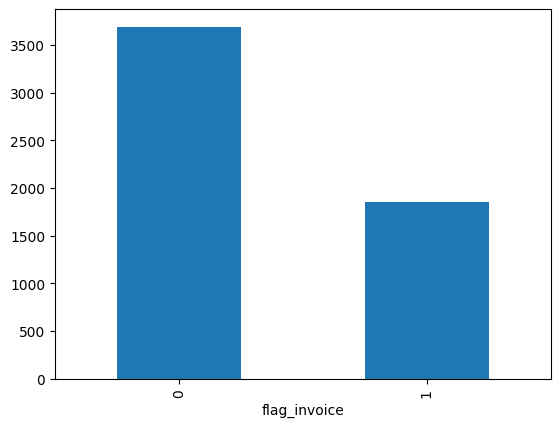

In [79]:
invoice_features_df["flag_invoice"].value_counts().plot(kind="bar")

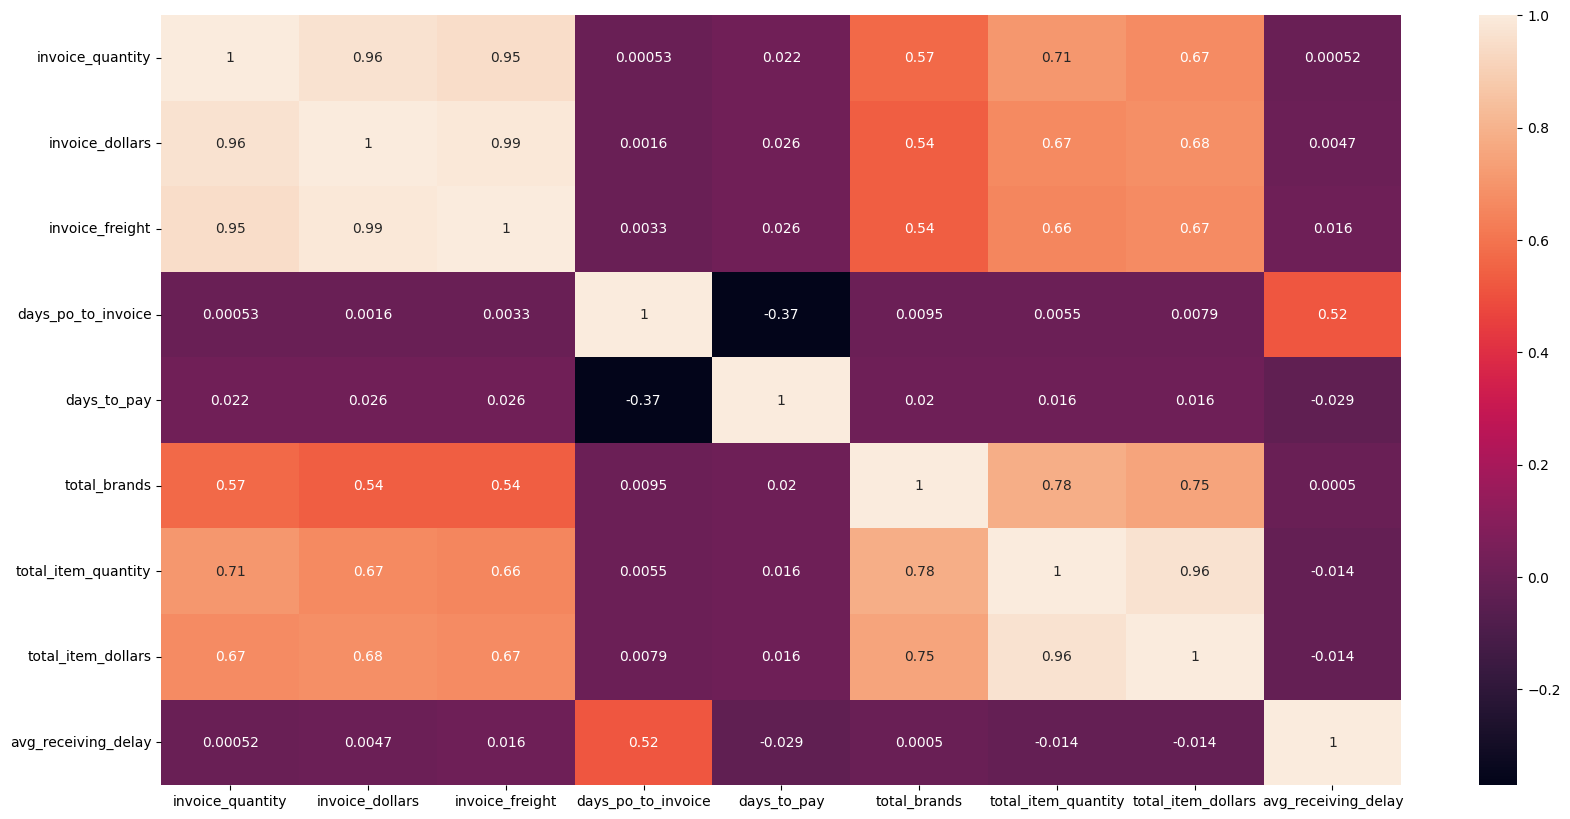

In [80]:

plt.figure(figsize=(20,10))
sns.heatmap(invoice_features_df.iloc[:, 1:-1].corr(), annot=True)
plt.show()

In [81]:
flagged = invoice_features_df[invoice_features_df["flag_invoice"] == 1]
normal = invoice_features_df[invoice_features_df["flag_invoice"] == 0]

In [82]:
siggnificant_features = []
non_significant_features = []

In [83]:
metrics=["invoice_quantity", "invoice_dollars", "invoice_freight", "days_po_to_invoice", "days_to_pay", "total_brands", "total_item_quantity", "total_item_dollars", "avg_receiving_delay"]

In [84]:
from scipy.stats import ttest_ind

for metric in metrics:
    flagged_mean = flagged[metric].mean()
    normal_mean = normal[metric].mean()

t_stat, p_value = ttest_ind(
    flagged [metric].dropna(),
    normal [metric].dropna(),
    equal_var=False
)

if p_value < 0.05:
    significant_features.append(metric)
    results.append({
    "metric": metric,
    "flagged_mean": flagged_mean.round(2),
    "normal_mean": normal_mean. round(2),
    "p_value": p_value.round(3)
    })
else:
    non_significant_features.append(metric)


In [85]:
non_significant_features


[]

In [86]:
significant_features

['invoice_quantity',
 'invoice_dollars',
 'invoice_freight',
 'days_po_to_invoice',
 'total_item_quantity',
 'total_item_dollars',
 'avg_receiving_delay',
 'avg_receiving_delay',
 'avg_receiving_delay']

In [87]:
results

[{'metric': 'invoice_quantity',
  'flagged_mean': np.float64(6728.28),
  'normal_mean': np.float64(5723.55),
  'p_value': np.float64(0.021)},
 {'metric': 'invoice_dollars',
  'flagged_mean': np.float64(65600.61),
  'normal_mean': np.float64(54302.64),
  'p_value': np.float64(0.008)},
 {'metric': 'invoice_freight',
  'flagged_mean': np.float64(334.02),
  'normal_mean': np.float64(276.89),
  'p_value': np.float64(0.008)},
 {'metric': 'days_po_to_invoice',
  'flagged_mean': np.float64(17.23),
  'normal_mean': np.float64(16.02),
  'p_value': np.float64(0.0)},
 {'metric': 'total_item_quantity',
  'flagged_mean': np.float64(6728.28),
  'normal_mean': np.float64(5723.55),
  'p_value': np.float64(0.021)},
 {'metric': 'total_item_dollars',
  'flagged_mean': np.float64(65600.61),
  'normal_mean': np.float64(54302.64),
  'p_value': np.float64(0.008)},
 {'metric': 'avg_receiving_delay',
  'flagged_mean': np.float64(8.47),
  'normal_mean': np.float64(7.27),
  'p_value': np.float64(0.0)},
 {'metric'

In [88]:
X = invoice_features_df[
    [
        "invoice_quantity",
        "invoice_dollars",
        "invoice_freight",
        "total_brands",
        "total_item_quantity",
        "days_po_to_invoice",
        "total_item_dollars",
    ]
]
y = invoice_features_df["flag_invoice"]

X.shape, y.shape

((5543, 7), (5543,))

In [89]:
X.describe().round()

,invoice_quantity,invoice_dollars,invoice_freight,total_brands,total_item_quantity,days_po_to_invoice,total_item_dollars
count,5543.0,5543.0,5543.0,5543.0,5543.0,5543.0,5543.0
mean,6059.0,58073.0,296.0,41.0,6059.0,16.0,58073.0
std,14453.0,140234.0,714.0,77.0,14453.0,3.0,140234.0
min,1.0,4.0,0.0,1.0,1.0,9.0,4.0
25%,83.0,968.0,5.0,3.0,83.0,14.0,968.0
50%,423.0,4765.0,25.0,7.0,423.0,16.0,4765.0
75%,5100.0,44587.0,230.0,46.0,5100.0,19.0,44587.0
max,141660.0,1660436.0,8468.0,807.0,141660.0,23.0,1660436.0


In [90]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y,
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


In [91]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier


In [92]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

model1 = LogisticRegression(random_state=42, max_iter=1000)
model1.fit(X_train_scaled, y_train)

model2 = DecisionTreeClassifier(random_state=42)
model2.fit(X_train_scaled, y_train)

model3 = RandomForestClassifier(random_state=42)
model3.fit(X_train_scaled, y_train)

print("Models trained successfully")

Models trained successfully


In [95]:
evaluate_model(model1, X_test_scaled, y_test, "Logistic Regression")
evaluate_model(model2, X_test_scaled, y_test, "Decision Tree Classifier")
evaluate_model(model3, X_test_scaled, y_test, "Random Forest Classifier")

Logistic Regression
Accuracy : 0.672
Precision: 0.579
Recall   : 0.059
F1 Score : 0.108
----------------------------------------
Decision Tree Classifier
Accuracy : 0.819
Precision: 0.735
Recall   : 0.714
F1 Score : 0.724
----------------------------------------
Random Forest Classifier
Accuracy : 0.876
Precision: 0.923
Recall   : 0.684
F1 Score : 0.786
----------------------------------------


In [96]:
model3.feature_importances_

array([0.14247549, 0.15605337, 0.14531062, 0.08294927, 0.17626282,
       0.07634923, 0.2205992 ])

In [99]:
feature_importance = pd.DataFrame(
    {"feature": X_train.columns, "importance": model3.feature_importances_}
).sort_values(by="importance", ascending=False)

feature_importance

,feature,importance
6,total_item_dollars,0.220599
4,total_item_quantity,0.176263
1,invoice_dollars,0.156053
2,invoice_freight,0.145311
0,invoice_quantity,0.142475
3,total_brands,0.082949
5,days_po_to_invoice,0.076349


In [101]:
X = invoice_features_df[
    [
        "invoice_quantity",
        "invoice_dollars",
        "invoice_freight",
        "total_item_quantity",
        "total_item_dollars",
    ]
]
y = invoice_features_df["flag_invoice"]

In [105]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

model3 = RandomForestClassifier(random_state=42)
model3.fit(X_train_scaled, y_train)
evaluate_model(model3, X_test_scaled, y_test, 'Random Forest Classifier')

Random Forest Classifier
Accuracy : 0.885
Precision: 0.935
Recall   : 0.716
F1 Score : 0.811
----------------------------------------


In [108]:
from sklearn.metrics import make_scorer, f1_score
from sklearn.model_selection import GridSearchCV

rf = RandomForestClassifier(random_state=42, n_jobs=-1)
param_grid = {
    "n_estimators": [100, 200, 300],
    "max_depth": [None, 4, 5, 6],
    "min_samples_split": [2, 3, 5],
    "min_samples_leaf": [1, 2, 5],
    "criterion": ["gini", "entropy"],
}
scorer = make_scorer(f1_score)
grid_search = GridSearchCV(
    estimator=rf, param_grid=param_grid, scoring=scorer, cv=5, verbose=2, n_jobs=-1
)
grid_search.fit(X_train_scaled, y_train)
evaluate_model(grid_search, X_test_scaled, y_test, "Random Forest Classifier")

Fitting 5 folds for each of 216 candidates, totalling 1080 fits
Random Forest Classifier
Accuracy : 0.890
Precision: 0.958
Recall   : 0.714
F1 Score : 0.818
----------------------------------------


In [109]:
from sklearn.metrics import confusion_matrix
confusion_matrix(grid_search.predict(X_test_scaled), y_test)

array([[713, 110],
       [ 12, 274]])

In [110]:
confusion_matrix(model3.predict(X_test_scaled), y_test)

array([[706, 109],
       [ 19, 275]])

In [111]:
grid_search.best_params_

{'criterion': 'gini',
 'max_depth': None,
 'min_samples_leaf': 1,
 'min_samples_split': 5,
 'n_estimators': 300}